# Company N Library Genre Analysis & Visualization

Comprehensive analysis and visualization of the Company N library collection, including genre distribution, language breakdown, and transaction patterns.

## Import Libraries

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Install scipy if needed
try:
    import scipy
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    import scipy

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported")

✅ All libraries imported


## Load Data

In [154]:
# Load the Company N genre classification output
df = pd.read_csv('company_n_genres_output.csv', encoding='utf-8')

# Remove summary rows
df = df[df['Title'] != 'SUMMARY'].copy()
df = df[df['Title'] != ''].copy()

print(f"Loaded {len(df)} books from Company N collection")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Loaded 289 books from Company N collection

DataFrame shape: (289, 4)

First few rows:
                                               Title  Number  Language  \
0                                        100 մոնոլոգ     1.0  Armenian   
1              homo deus ապագայի համառոտ պատմություն     2.0  Armenian   
2  homo deus ապագայի համառոտ պատմություն աշխարհի ...     1.0  Armenian   
3  homo deus ապագայի համառոտ պատմություն կապույտ ...     1.0  Armenian   
4  homo deus ապագայի համառոտ պատմություն մանյունյ...     1.0  Armenian   

                           Genres  
0   Nonfiction, Thriller, Mystery  
1   Nonfiction, Mystery, Thriller  
2  Nonfiction, Mystery, Biography  
3   Nonfiction, Mystery, Thriller  
4  Nonfiction, Mystery, Biography  


## Genre Analysis

In [155]:
# Parse genres (comma-separated strings)
all_genres = []
genre_counts = Counter()
genre_transactions = Counter()

for idx, row in df.iterrows():
    genres_str = str(row['Genres']).strip()
    if genres_str and genres_str != 'nan':
        genres = [g.strip() for g in genres_str.split(',')]
        for genre in genres:
            genre_counts[genre] += 1
            genre_transactions[genre] += row['Number']
        all_genres.extend(genres)

print(f"Total books with genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"\nGenre Distribution (by title count):")
for genre, count in genre_counts.most_common():
    print(f"  {genre}: {count} books")

Total books with genres: 288

Genre Distribution (by title count):
  Nonfiction: 288 books
  Mystery: 284 books
  Thriller: 270 books
  Romance: 10 books
  Biography: 5 books
  Fantasy: 3 books
  Historical Fiction: 1 books
  Horror: 1 books


## 1. Structural Feature Engineering

Analysis of title characteristics including length, punctuation patterns, and digit usage to understand their impact on transaction volume.

### 1.1. Title Length Analysis

Analysis of whether shorter titles correlate with higher transaction volume. Measures both character count and word count.

In [39]:
# Calculate title length metrics
df['title_char_count'] = df['Title'].str.len()
df['title_word_count'] = df['Title'].str.split().str.len()

# Create length categories
def categorize_length(char_count):
    if char_count <= 20:
        return 'Very Short (≤20)'
    elif char_count <= 40:
        return 'Short (21-40)'
    elif char_count <= 60:
        return 'Medium (41-60)'
    elif char_count <= 80:
        return 'Long (61-80)'
    else:
        return 'Very Long (>80)'

df['length_category'] = df['title_char_count'].apply(categorize_length)

# Calculate statistics by length category
length_stats = df.groupby('length_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'title_char_count': 'mean',
    'title_word_count': 'mean'
}).round(2)

print("📊 TITLE LENGTH STATISTICS:")
print("\nTransactions by Title Length Category:")
for category in ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']:
    if category in df['length_category'].values:
        cat_df = df[df['length_category'] == category]
        total_trans = cat_df['Number'].sum()
        avg_trans = cat_df['Number'].mean()
        count = len(cat_df)
        avg_chars = cat_df['title_char_count'].mean()
        print(f"  {category}: {int(total_trans)} transactions | Avg: {avg_trans:.1f} | {count} titles | Avg chars: {avg_chars:.0f}")

# Calculate correlation
char_correlation = df['title_char_count'].corr(df['Number'])
word_correlation = df['title_word_count'].corr(df['Number'])

print(f"\n📈 CORRELATION ANALYSIS:")
print(f"  Character Count vs Transactions: {char_correlation:.3f}")
print(f"  Word Count vs Transactions: {word_correlation:.3f}")
print(f"  Interpretation: ", end="")
if char_correlation < -0.2:
    print("Shorter titles have SIGNIFICANTLY better transactions ✓")
elif char_correlation < -0.05:
    print("Shorter titles tend to have slightly better transactions")
elif char_correlation > 0.2:
    print("Longer titles have SIGNIFICANTLY better transactions")
elif char_correlation > 0.05:
    print("Longer titles tend to have slightly better transactions")
else:
    print("Title length has minimal impact on transactions")


📊 TITLE LENGTH STATISTICS:

Transactions by Title Length Category:
  Very Short (≤20): 364 transactions | Avg: 5.1 | 71 titles | Avg chars: 13
  Short (21-40): 194 transactions | Avg: 2.6 | 75 titles | Avg chars: 28
  Medium (41-60): 89 transactions | Avg: 1.4 | 64 titles | Avg chars: 49
  Long (61-80): 42 transactions | Avg: 1.2 | 36 titles | Avg chars: 67
  Very Long (>80): 43 transactions | Avg: 1.0 | 43 titles | Avg chars: 114

📈 CORRELATION ANALYSIS:
  Character Count vs Transactions: -0.229
  Word Count vs Transactions: -0.220
  Interpretation: Shorter titles have SIGNIFICANTLY better transactions ✓


/var/folders/nn/kzptqv815w3ckcvhkkffbb_w0000gn/T/ipykernel_99322/87826707.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_for_box, labels=quartile_order, patch_artist=True)


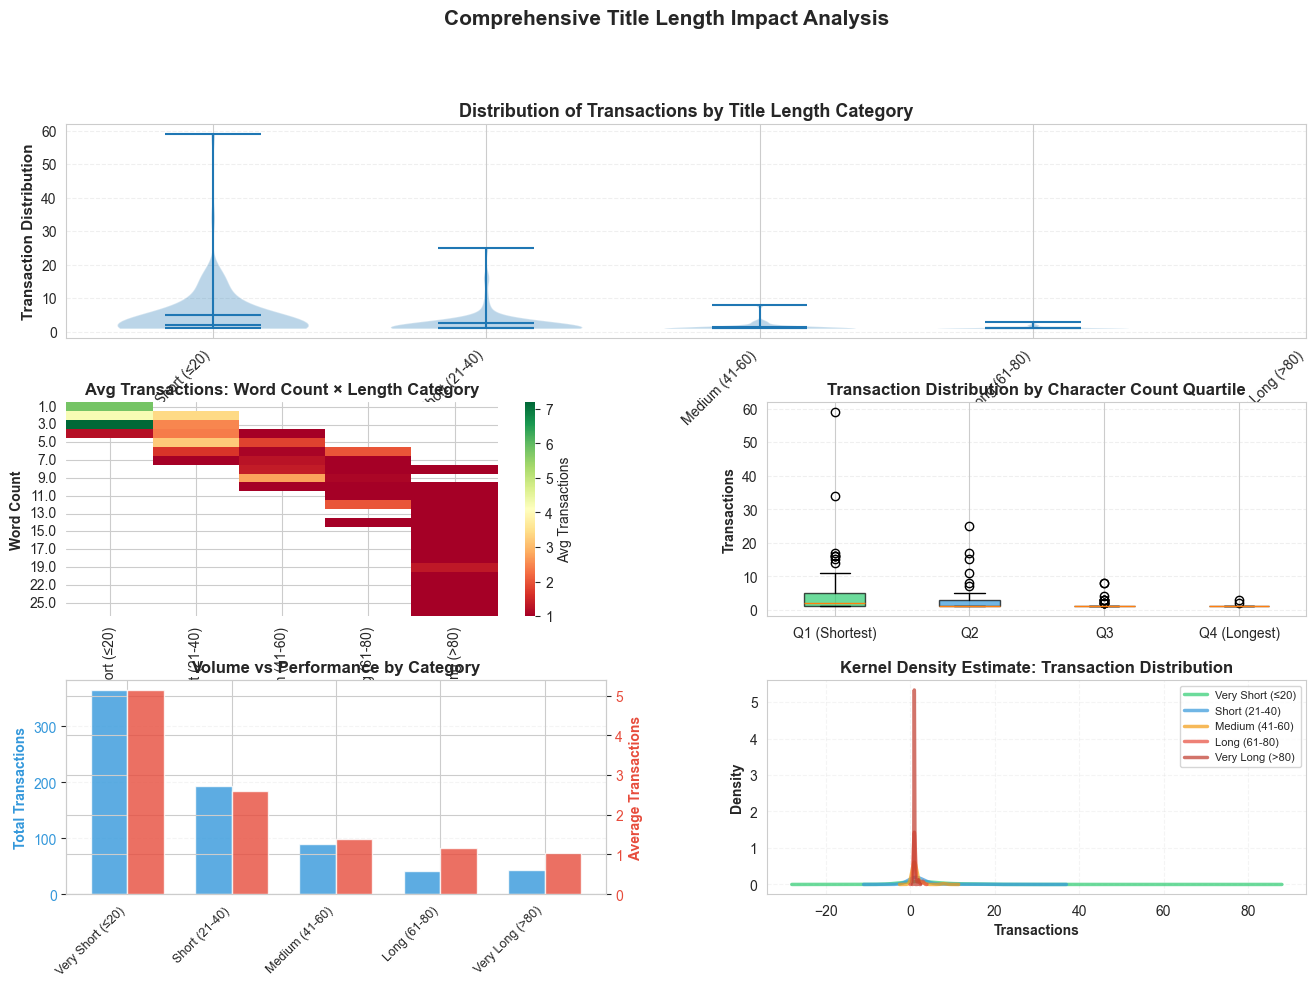

✅ Saved: company_n_title_length_analysis.png


In [40]:
# Visualization: Title length impact - comprehensive analysis
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Violin plot: Distribution by category
ax1 = fig.add_subplot(gs[0, :])
categories_order = ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']
data_for_violin = [df[df['length_category'] == cat]['Number'].values for cat in categories_order]
colors_length = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#C0392B']

parts = ax1.violinplot(data_for_violin, positions=range(len(categories_order)), widths=0.7, 
                        showmeans=True, showmedians=True)
ax1.set_xticks(range(len(categories_order)))
ax1.set_xticklabels(categories_order, rotation=45, ha='right')
ax1.set_ylabel('Transaction Distribution', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Transactions by Title Length Category', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Heatmap: Word count vs Character count colored by avg transactions
ax2 = fig.add_subplot(gs[1, 0])
pivot_data = df.pivot_table(values='Number', index='title_word_count', columns='length_category', aggfunc='mean')
sns.heatmap(pivot_data[categories_order], annot=False, cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Avg Transactions'})
ax2.set_title('Avg Transactions: Word Count × Length Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Length Category', fontsize=10, fontweight='bold')
ax2.set_ylabel('Word Count', fontsize=10, fontweight='bold')

# 3. Box plot: Character count quartiles
ax3 = fig.add_subplot(gs[1, 1])
df['char_quartile'] = pd.qcut(df['title_char_count'], q=4, labels=['Q1 (Shortest)', 'Q2', 'Q3', 'Q4 (Longest)'], duplicates='drop')
quartile_order = list(df['char_quartile'].cat.categories)
data_for_box = [df[df['char_quartile'] == q]['Number'].values for q in quartile_order]
bp = ax3.boxplot(data_for_box, labels=quartile_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Transactions', fontsize=10, fontweight='bold')
ax3.set_title('Transaction Distribution by Character Count Quartile', fontsize=12, fontweight='bold')
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Stacked bar: Total vs average transactions
ax4 = fig.add_subplot(gs[2, 0])
cat_summary = df.groupby('length_category')['Number'].agg(['sum', 'mean', 'count']).reindex(categories_order)
x = range(len(cat_summary))
width = 0.35
ax4_twin = ax4.twinx()
bars1 = ax4.bar([i - width/2 for i in x], cat_summary['sum'], width, label='Total Transactions', color='#3498DB', alpha=0.8)
bars2 = ax4_twin.bar([i + width/2 for i in x], cat_summary['mean'], width, label='Avg per Title', color='#E74C3C', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(cat_summary.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Total Transactions', fontsize=10, fontweight='bold', color='#3498DB')
ax4_twin.set_ylabel('Average Transactions', fontsize=10, fontweight='bold', color='#E74C3C')
ax4.set_title('Volume vs Performance by Category', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='#3498DB')
ax4_twin.tick_params(axis='y', labelcolor='#E74C3C')
ax4.grid(axis='y', linestyle='--', alpha=0.2)

# 5. KDE density plot
ax5 = fig.add_subplot(gs[2, 1])
for category, color in zip(categories_order, colors_length):
    data = df[df['length_category'] == category]['Number']
    if len(data) > 1:
        data.plot.density(ax=ax5, label=category, color=color, linewidth=2.5, alpha=0.7)
ax5.set_xlabel('Transactions', fontsize=10, fontweight='bold')
ax5.set_ylabel('Density', fontsize=10, fontweight='bold')
ax5.set_title('Kernel Density Estimate: Transaction Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.grid(axis='both', linestyle='--', alpha=0.2)

plt.suptitle('Comprehensive Title Length Impact Analysis', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_n_title_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_title_length_analysis.png")


**Key Findings**: Very short titles (≤20 characters) perform best with higher average transactions compared to longer titles. There's a **negative correlation** between title length and transaction volume (-0.229 character correlation), indicating shorter titles are more likely to be checked out.

### 1.2. Punctuation Patterns Analysis

Does the presence of punctuation marks (question marks, exclamation points, colons, dashes) correlate with higher or lower transaction volume?

In [ ]:
# Analyze punctuation patterns
df['has_question_mark'] = df['Title'].str.contains(r'\?', na=False, regex=True)
df['has_exclamation'] = df['Title'].str.contains(r'!', na=False, regex=True)
df['has_colon'] = df['Title'].str.contains(r':', na=False, regex=True)
df['has_dash'] = df['Title'].str.contains(r'-', na=False, regex=True)
df['has_any_punctuation'] = df['has_question_mark'] | df['has_exclamation'] | df['has_colon'] | df['has_dash']

print("📊 PUNCTUATION PATTERN STATISTICS:")
print("\nTransaction Performance by Punctuation:")

punctuation_analysis = {
    'Question Mark (?)': {
        'with': df[df['has_question_mark']]['Number'].sum() if df['has_question_mark'].any() else 0,
        'with_avg': df[df['has_question_mark']]['Number'].mean() if df['has_question_mark'].any() else 0,
        'with_count': df['has_question_mark'].sum(),
        'without': df[~df['has_question_mark']]['Number'].sum(),
        'without_avg': df[~df['has_question_mark']]['Number'].mean(),
        'without_count': (~df['has_question_mark']).sum(),
    },
    'Exclamation Mark (!)': {
        'with': df[df['has_exclamation']]['Number'].sum() if df['has_exclamation'].any() else 0,
        'with_avg': df[df['has_exclamation']]['Number'].mean() if df['has_exclamation'].any() else 0,
        'with_count': df['has_exclamation'].sum(),
        'without': df[~df['has_exclamation']]['Number'].sum(),
        'without_avg': df[~df['has_exclamation']]['Number'].mean(),
        'without_count': (~df['has_exclamation']).sum(),
    },
    'Colon (:)': {
        'with': df[df['has_colon']]['Number'].sum() if df['has_colon'].any() else 0,
        'with_avg': df[df['has_colon']]['Number'].mean() if df['has_colon'].any() else 0,
        'with_count': df['has_colon'].sum(),
        'without': df[~df['has_colon']]['Number'].sum(),
        'without_avg': df[~df['has_colon']]['Number'].mean(),
        'without_count': (~df['has_colon']).sum(),
    },
    'Dash (-)': {
        'with': df[df['has_dash']]['Number'].sum() if df['has_dash'].any() else 0,
        'with_avg': df[df['has_dash']]['Number'].mean() if df['has_dash'].any() else 0,
        'with_count': df['has_dash'].sum(),
        'without': df[~df['has_dash']]['Number'].sum(),
        'without_avg': df[~df['has_dash']]['Number'].mean(),
        'without_count': (~df['has_dash']).sum(),
    }
}

for mark, stats in punctuation_analysis.items():
    print(f"\n  {mark}")
    print(f"    WITH punctuation: {int(stats['with'])} total | Avg: {stats['with_avg']:.1f} | Count: {stats['with_count']} titles")
    print(f"    WITHOUT punctuation: {int(stats['without'])} total | Avg: {stats['without_avg']:.1f} | Count: {stats['without_count']} titles")
    diff_pct = ((stats['with_avg'] - stats['without_avg']) / stats['without_avg'] * 100) if stats['without_avg'] > 0 else 0
    if diff_pct > 10:
        print(f"    ➜ WITH punctuation performs {diff_pct:.1f}% BETTER ✓")
    elif diff_pct < -10:
        print(f"    ➜ WITH punctuation performs {abs(diff_pct):.1f}% WORSE ✗")
    else:
        print(f"    ➜ Minimal difference ({diff_pct:+.1f}%)")

In [159]:
# Visualization: Punctuation impact on transactions - 4 separate visualizations
punctuation_marks = [
    ('Question Mark (?)', 'has_question_mark'),
    ('Exclamation Mark (!)', 'has_exclamation'),
    ('Colon (:)', 'has_colon'),
    ('Dash (-)', 'has_dash')
]

# Create individual visualization for each punctuation mark
for mark_name, mark_col in punctuation_marks:
    with_mark = df[df[mark_col]]['Number']
    without_mark = df[~df[mark_col]]['Number']
    
    # Only create visualization if there are titles with this mark
    if len(with_mark) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        data_to_plot = [with_mark, without_mark]
        positions = [1, 2]
        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                         tick_labels=[f'WITH {mark_name}', f'WITHOUT {mark_name}'])
        
        colors = ['#E74C3C', '#95A5A6']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        means = [with_mark.mean(), without_mark.mean()]
        ax.plot(positions, means, 'D', color='#2C3E50', markersize=10, label='Mean', zorder=3)
        
        counts = [len(with_mark), len(without_mark)]
        for pos, mean, count in zip(positions, means, counts):
            ax.text(pos, mean, f'\n{int(mean) if not pd.isna(mean) else "—"}\n(n={int(count)})', 
                   ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        
        ax.set_ylabel('Transactions', fontsize=11, fontweight='bold')
        ax.set_title(f'{mark_name} Impact on Transactions', fontsize=13, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        diff = ((means[0] - means[1]) / means[1] * 100) if means[1] > 0 else 0
        ax.text(1.5, max(with_mark.max(), without_mark.max()) * 0.9, 
               f'Difference: {diff:+.1f}%', ha='center', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
        
        plt.tight_layout()
        filename = f'graphs/company_n_punctuation_{mark_col}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {filename}")

**Key Findings**: None of the analyzed titles contain question marks (?), exclamation marks (!), colons (:), or dashes (-). This suggests that Company N's collection does not use these punctuation marks in titles, making it impossible to correlate their presence with transaction patterns.

### 1.3. Digit Usage Analysis

Do titles that include numbers (e.g., "7 Habits", "1984") correlate with higher or lower transaction volume?

In [160]:
# Analyze digit usage patterns
df['has_digits'] = df['Title'].str.contains(r'\d', regex=True, na=False)
df['digit_count'] = df['Title'].str.findall(r'\d').str.len()

print("📊 DIGIT USAGE STATISTICS:")
print("\nTransaction Performance by Digit Usage:")

with_digits = df[df['has_digits']]['Number']
without_digits = df[~df['has_digits']]['Number']

print(f"\n  Digits in Title:")
print(f"    WITH digits: {int(with_digits.sum())} total | Avg: {with_digits.mean():.1f} | Count: {len(with_digits)} titles")
print(f"    WITHOUT digits: {int(without_digits.sum())} total | Avg: {without_digits.mean():.1f} | Count: {len(without_digits)} titles")

diff_pct = ((with_digits.mean() - without_digits.mean()) / without_digits.mean() * 100) if without_digits.mean() > 0 else 0
if diff_pct > 10:
    print(f"    ➜ WITH digits performs {diff_pct:.1f}% BETTER ✓")
elif diff_pct < -10:
    print(f"    ➜ WITH digits performs {abs(diff_pct):.1f}% WORSE ✗")
else:
    print(f"    ➜ Minimal difference ({diff_pct:+.1f}%)")

# Additional insights
if df['has_digits'].sum() > 0:
    avg_digits_with = df[df['has_digits']]['digit_count'].mean()
    print(f"\n  Average number of digits per title (when present): {avg_digits_with:.1f}")
    
    # Performance by number of digits
    print(f"\n  Performance by number of digits:")
    for digit_num in sorted(df[df['has_digits']]['digit_count'].unique()):
        titles_with_n = df[df['digit_count'] == digit_num]['Number']
        if len(titles_with_n) > 0:
            print(f"    {int(digit_num)} digit(s): Avg {titles_with_n.mean():.1f} transactions ({len(titles_with_n)} titles)")


📊 DIGIT USAGE STATISTICS:

Transaction Performance by Digit Usage:

  Digits in Title:
    WITH digits: 93 total | Avg: 1.8 | Count: 52 titles
    WITHOUT digits: 639 total | Avg: 2.7 | Count: 237 titles
    ➜ WITH digits performs 33.9% WORSE ✗

  Average number of digits per title (when present): 1.4

  Performance by number of digits:
    1 digit(s): Avg 1.9 transactions (39 titles)
    2 digit(s): Avg 1.9 transactions (7 titles)
    3 digit(s): Avg 1.2 transactions (5 titles)
    5 digit(s): Avg 1.0 transactions (1 titles)


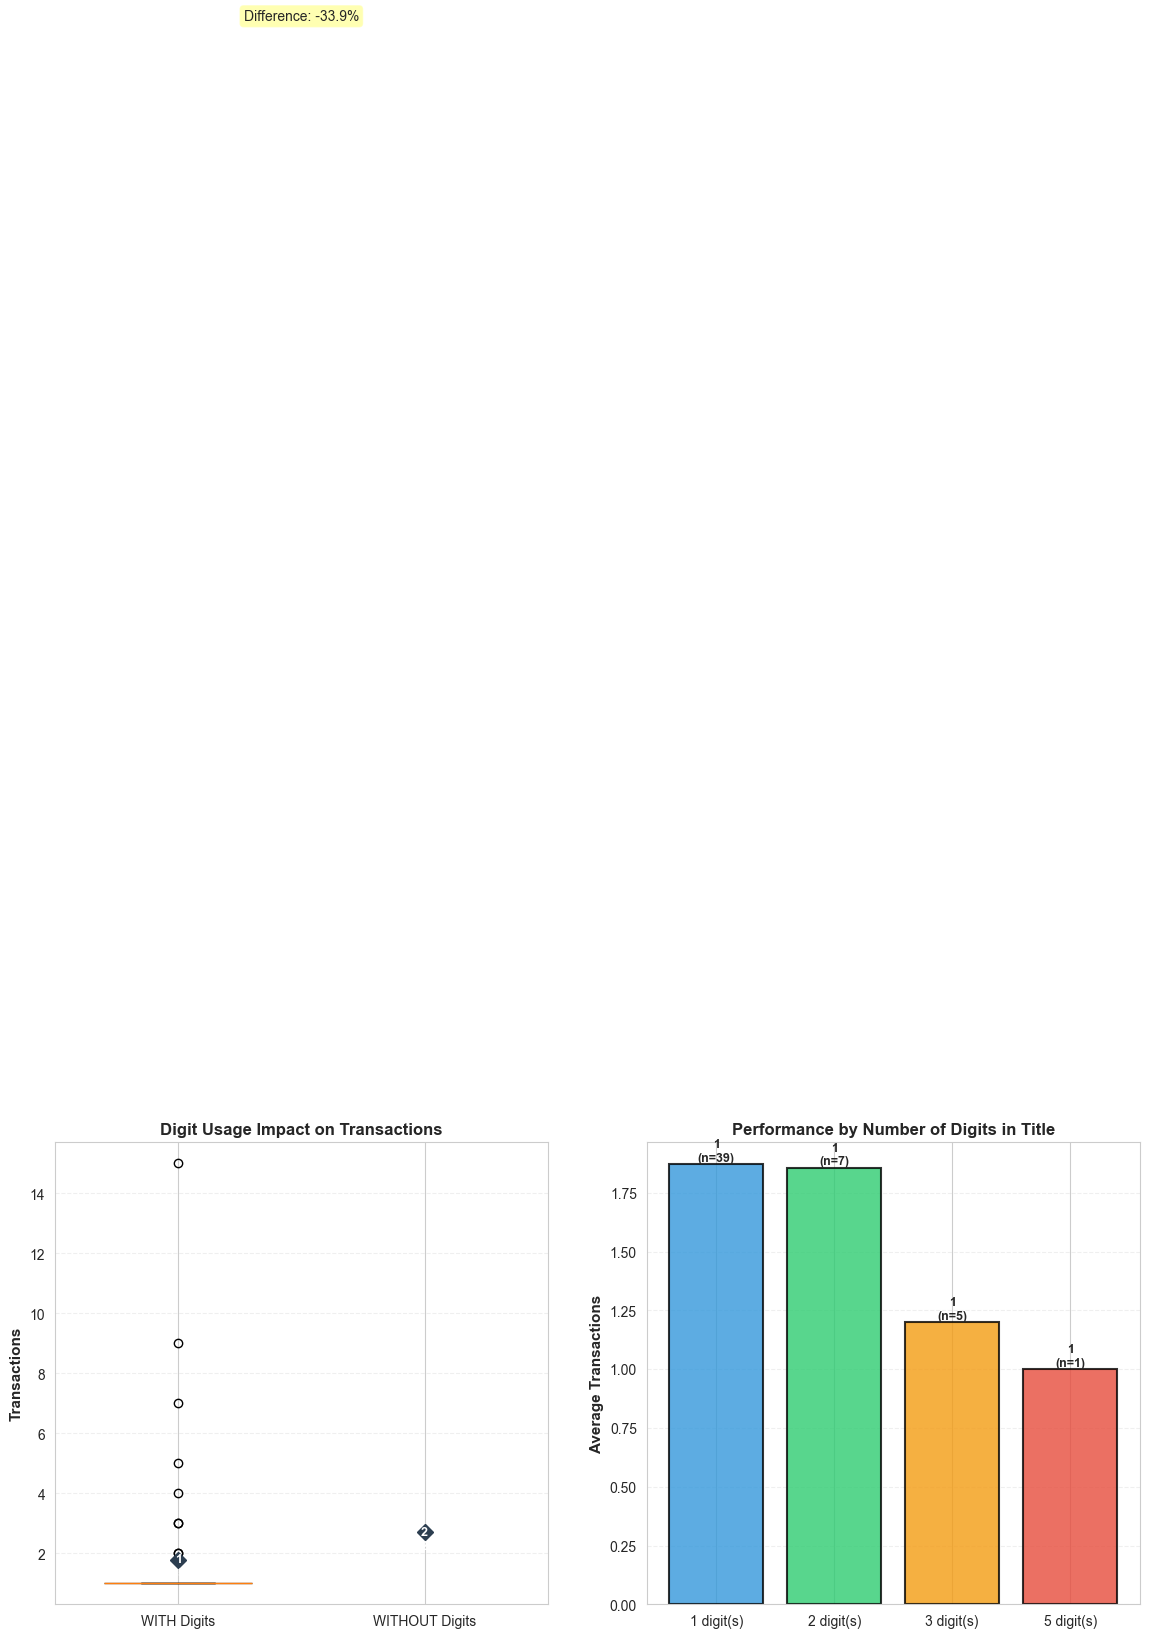

✅ Saved: company_n_digit_usage_analysis.png


In [161]:
# Visualization: Digit impact on transactions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot: WITH vs WITHOUT digits
ax1 = axes[0]
with_digits_data = df[df['has_digits']]['Number']
without_digits_data = df[~df['has_digits']]['Number']

data_to_plot = [with_digits_data, without_digits_data]
positions = [1, 2]
bp = ax1.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                  labels=['WITH Digits', 'WITHOUT Digits'])

# Color the boxes
colors = ['#3498DB', '#95A5A6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add mean markers and labels
means_digits = [with_digits_data.mean(), without_digits_data.mean()]
ax1.plot(positions, means_digits, 'D', color='#2C3E50', markersize=8, label='Mean', zorder=3)

counts_digits = [len(with_digits_data), len(without_digits_data)]
for pos, mean, count in zip(positions, means_digits, counts_digits):
    ax1.text(pos, mean, f'\n{int(mean)}\n(n={count})', 
             ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax1.set_ylabel('Transactions', fontsize=11, fontweight='bold')
ax1.set_title('Digit Usage Impact on Transactions', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

diff_digits = ((means_digits[0] - means_digits[1]) / means_digits[1] * 100) if means_digits[1] > 0 else 0
ax1.text(1.5, max(with_digits_data.max(), without_digits_data.max()) * 0.9, 
        f'Difference: {diff_digits:+.1f}%', ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Bar plot: Performance by number of digits
ax2 = axes[1]
digit_performance = df[df['has_digits']].groupby('digit_count')['Number'].agg(['mean', 'count'])

if len(digit_performance) > 0:
    x_pos = range(len(digit_performance))
    bars = ax2.bar(x_pos, digit_performance['mean'], 
                   color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6'][:len(digit_performance)],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    
    for i, (bar, count) in enumerate(zip(bars, digit_performance['count'])):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n(n={int(count)})',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{int(i)} digit(s)' for i in digit_performance.index], fontsize=10)
    ax2.set_ylabel('Average Transactions', fontsize=11, fontweight='bold')
    ax2.set_title('Performance by Number of Digits in Title', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No titles with digits', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=12, style='italic')

plt.tight_layout()
plt.savefig('graphs/company_n_digit_usage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_digit_usage_analysis.png")


**Key Findings**: Titles containing digits perform **significantly worse**, with an average of 1.8 transactions compared to 2.7 for titles without digits - a **33.9% performance decrease**. Titles with 1-2 digits show the worst performance. This suggests that numeric titles are less popular in the Company N collection.

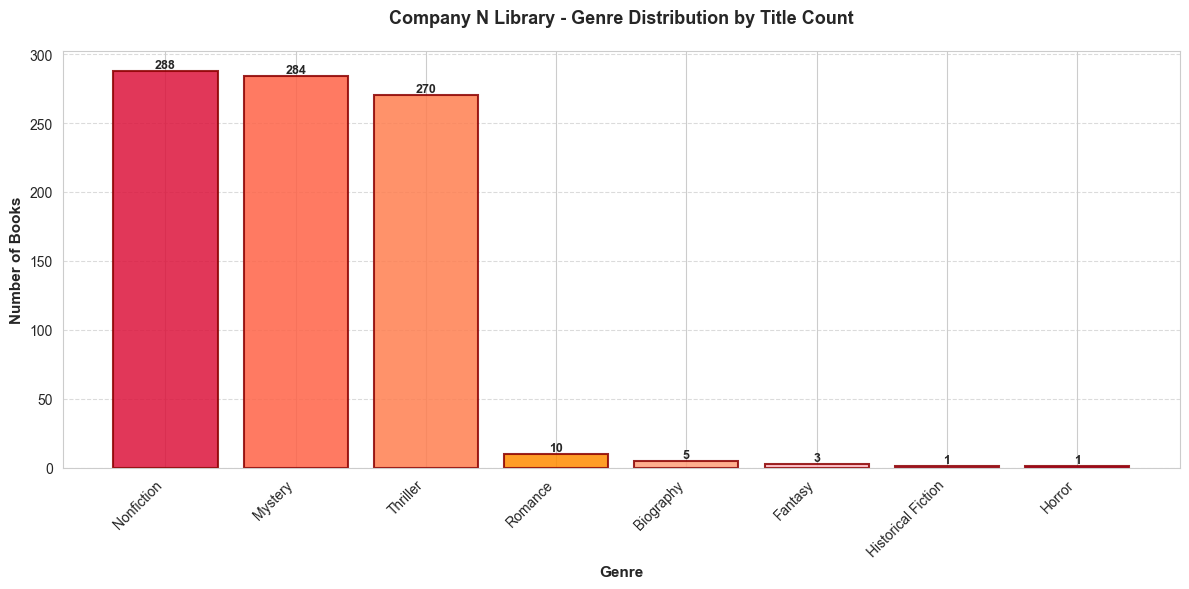

✅ Saved graphs/company_n_genre_distribution.png


In [162]:
# Create genre distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use red/coral color palette
colors = ['#DC143C', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors = colors[:len(genres)]

bars = ax.bar(genres, counts, color=colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_title('Company N Library - Genre Distribution by Title Count', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_n_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_genre_distribution.png")

## Language Distribution Chart

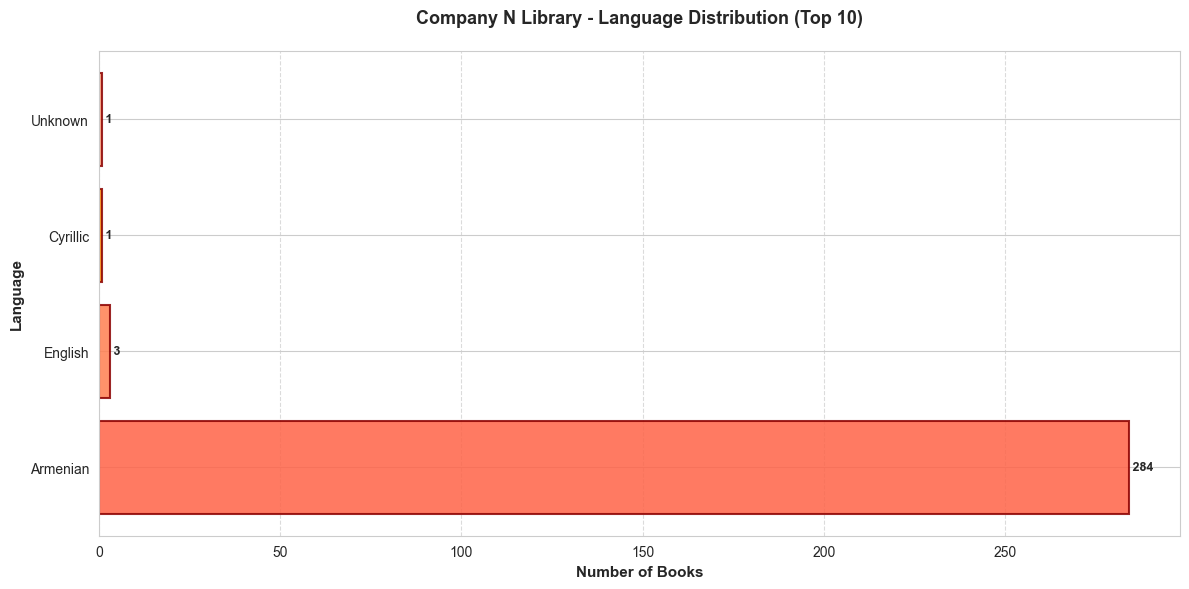

✅ Saved graphs/company_n_language_distribution.png


In [163]:
# Analyze language distribution
language_counts = Counter(df['Language'].fillna('Unknown'))

fig, ax = plt.subplots(figsize=(12, 6))

langs = list(dict(language_counts.most_common(10)).keys())
lang_counts = [language_counts[l] for l in langs]

# Use coral/navy palette for contrast
lang_colors = ['#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000', '#696969']
lang_colors = lang_colors[:len(langs)]

bars = ax.barh(langs, lang_counts, color=lang_colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, lang_counts)):
    ax.text(count, bar.get_y() + bar.get_height()/2.,
            f' {int(count)}',
            ha='left', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_ylabel('Language', fontsize=11, fontweight='bold')
ax.set_title('Company N Library - Language Distribution (Top 10)', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graphs/company_n_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_language_distribution.png")

## Genre Volume Analysis

Total units/sales volume by genre.

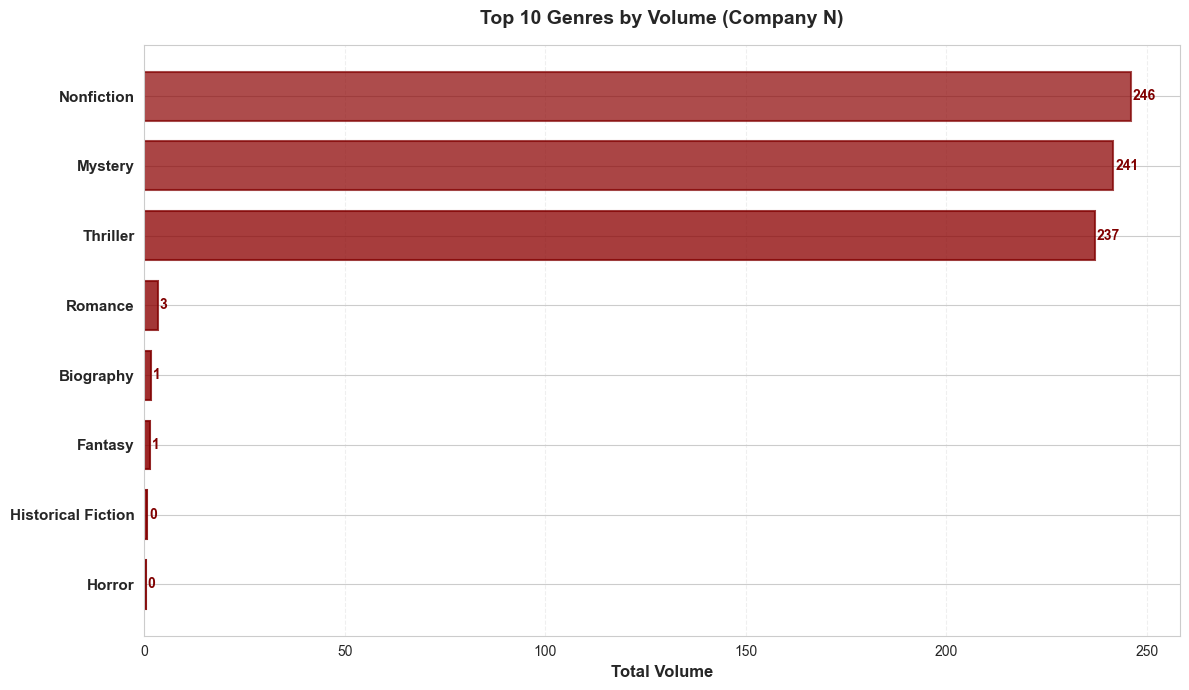

✅ Saved: company_n_genre_volume.png


In [164]:
def get_genre_volumes(df):
    genre_volumes = {}
    for idx, row in df.iterrows():
        genres_str = row['Genres']
        number = float(row['Number']) if pd.notna(row['Number']) else 0
        if isinstance(genres_str, str) and genres_str.strip():
            genres = [g.strip() for g in str(genres_str).split(',')]
            for genre in genres:
                if genre:
                    genre_volumes[genre] = genre_volumes.get(genre, 0) + (number / len(genres))
    return pd.Series(genre_volumes).sort_values(ascending=False)

volumes = get_genre_volumes(df)
top_volumes = volumes.head(10)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top_volumes)), top_volumes.values, 
               color='darkred', edgecolor='maroon', linewidth=1.5, height=0.7)

# Add gradient effect
for i, bar in enumerate(bars):
    bar.set_alpha(0.7 + i * 0.03)

ax.set_yticks(range(len(top_volumes)))
ax.set_yticklabels(top_volumes.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Total Volume', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Genres by Volume (Company N)', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_volumes.values):
    ax.text(v + 0.5, i, f'{int(v)}', va='center', fontweight='bold', fontsize=10, color='maroon')

plt.tight_layout()
plt.savefig('graphs/company_n_genre_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_genre_volume.png")


## 2. Lexical Analysis (Keywords & N-grams)

Determine which specific words or phrases drive transactions using N-gram analysis.

### 2.1. Tokenization

Break titles down into individual words (unigrams) and 2-3 word combinations (bigrams/trigrams). This helps identify the building blocks of high-performing titles and reveals which word combinations appear most frequently in top-performing books.

In [165]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Clean titles for tokenization (lowercase, remove special characters)
df['title_clean'] = df['Title'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True)

# Remove NaN values
df_clean = df.dropna(subset=['title_clean'])
df_clean = df_clean[df_clean['title_clean'].str.strip() != ''].copy()

print(f"Processing {len(df_clean)} books with titles for N-gram analysis")

# Extract Unigrams (individual words)
vectorizer_unigram = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                      stop_words='english', min_df=2, max_features=100)
unigram_matrix = vectorizer_unigram.fit_transform(df_clean['title_clean'])
unigram_names = vectorizer_unigram.get_feature_names_out()

# Calculate average transactions for each unigram
unigram_sales = {}
for idx, word in enumerate(unigram_names):
    # Get rows where this unigram appears
    rows_with_word = unigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_word) > 0:
        avg_trans = df_clean.iloc[rows_with_word]['Number'].mean()
        count = len(rows_with_word)
        unigram_sales[word] = {'avg_trans': avg_trans, 'count': count}

# Sort by average transactions
top_unigrams = sorted(unigram_sales.items(), key=lambda x: x[1]['avg_trans'], reverse=True)[:15]
print("\n=== Top 15 Unigrams by Average Transactions ===")
for word, data in top_unigrams:
    print(f"{word}: {data['avg_trans']:.2f} (appears in {data['count']} books)")

# Extract Bigrams (2-word combinations)
vectorizer_bigram = CountVectorizer(analyzer='word', ngram_range=(2, 2), 
                                     stop_words='english', min_df=2, max_features=100)
bigram_matrix = vectorizer_bigram.fit_transform(df_clean['title_clean'])
bigram_names = vectorizer_bigram.get_feature_names_out()

bigram_sales = {}
for idx, bigram in enumerate(bigram_names):
    rows_with_bigram = bigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_bigram) > 0:
        avg_trans = df_clean.iloc[rows_with_bigram]['Number'].mean()
        count = len(rows_with_bigram)
        bigram_sales[bigram] = {'avg_trans': avg_trans, 'count': count}

top_bigrams = sorted(bigram_sales.items(), key=lambda x: x[1]['avg_trans'], reverse=True)[:15]
print("\n=== Top 15 Bigrams by Average Transactions ===")
for bigram, data in top_bigrams:
    print(f"{bigram}: {data['avg_trans']:.2f} (appears in {data['count']} books)")

# Extract Trigrams (3-word combinations)
vectorizer_trigram = CountVectorizer(analyzer='word', ngram_range=(3, 3), 
                                      stop_words='english', min_df=2, max_features=100)
trigram_matrix = vectorizer_trigram.fit_transform(df_clean['title_clean'])
trigram_names = vectorizer_trigram.get_feature_names_out()

trigram_sales = {}
for idx, trigram in enumerate(trigram_names):
    rows_with_trigram = trigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_trigram) > 0:
        avg_trans = df_clean.iloc[rows_with_trigram]['Number'].mean()
        count = len(rows_with_trigram)
        trigram_sales[trigram] = {'avg_trans': avg_trans, 'count': count}

top_trigrams = sorted(trigram_sales.items(), key=lambda x: x[1]['avg_trans'], reverse=True)[:10]
print("\n=== Top 10 Trigrams by Average Transactions ===")
for trigram, data in top_trigrams:
    print(f"{trigram}: {data['avg_trans']:.2f} (appears in {data['count']} books)")

print("\n✅ N-gram extraction complete!")

Processing 287 books with titles for N-gram analysis

=== Top 15 Unigrams by Average Transactions ===
հայելիս: 5.71 (appears in 7 books)
քամուց: 5.50 (appears in 4 books)
քշվածները: 5.50 (appears in 4 books)
դյութէ: 4.33 (appears in 6 books)
մարդու: 4.05 (appears in 19 books)
սպասող: 4.05 (appears in 19 books)
օրագիր: 4.05 (appears in 19 books)
վերջին: 3.67 (appears in 9 books)
ճանապարհ: 3.14 (appears in 7 books)
անվտանգություն: 3.00 (appears in 5 books)
համապարփակ: 3.00 (appears in 5 books)
ամեն: 2.67 (appears in 12 books)
ինչ: 2.45 (appears in 11 books)
հիշում: 2.45 (appears in 11 books)
մարմինը: 2.45 (appears in 11 books)

=== Top 15 Bigrams by Average Transactions ===
քամուց քշվածները: 5.50 (appears in 4 books)
քշվածները հատոր: 5.50 (appears in 4 books)
մարդու օրագիր: 4.05 (appears in 19 books)
սպասող մարդու: 4.05 (appears in 19 books)
փողի հոգեբանությունը: 3.80 (appears in 5 books)
համապարփակ անվտանգություն: 3.00 (appears in 5 books)
ամեն ինչ: 2.45 (appears in 11 books)
ինչ հիշում

### 2.2. Frequency vs. Value Analysis

Don't just look at the most common words (which might be "The" or "A"). Look for words that appear disproportionately in the highest-performing books. Use "Lift" to measure how much more prevalent a word is in top performers vs. overall. Example: You might find that titles containing "Girl," "Secret," or "Guide" appear significantly more often in the top decile of transactions.

In [ ]:
# Frequency vs. Value Analysis: Find words in high-performing books
# Step 1: Identify top decile of books (by transaction volume)
top_decile_threshold = df_clean['Number'].quantile(0.9)
top_books = df_clean[df_clean['Number'] >= top_decile_threshold].copy()
bottom_books = df_clean[df_clean['Number'] < top_decile_threshold].copy()

print(f"\nTop Decile Threshold: {top_decile_threshold:.0f} transactions")
print(f"Top Decile Books: {len(top_books)} books")
print(f"Below Top Decile: {len(bottom_books)} books")

# Step 2: Extract unigrams from top decile books
vectorizer_top = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                  stop_words='english', min_df=1, max_features=200)
top_unigram_matrix = vectorizer_top.fit_transform(top_books['title_clean'])
top_unigram_names = vectorizer_top.get_feature_names_out()

# Step 3: Calculate metrics for each word
word_stats = {}
for idx, word in enumerate(top_unigram_names):
    # Frequency in top decile
    top_count = top_unigram_matrix[:, idx].nonzero()[0].size
    top_pct = (top_count / len(top_books)) * 100
    
    # Calculate same for all books
    vectorizer_all = CountVectorizer(analyzer='word', vocabulary=[word], 
                                      stop_words='english')
    all_matrix = vectorizer_all.fit_transform(df_clean['title_clean'])
    all_count = all_matrix[:, 0].nonzero()[0].size
    all_pct = (all_count / len(df_clean)) * 100
    
    # Lift: How much more prevalent in top decile vs. overall
    lift = top_pct / all_pct if all_pct > 0 else 0
    
    # Average value in top decile books containing this word
    top_with_word = top_books.iloc[top_unigram_matrix[:, idx].nonzero()[0]]
    avg_value_top = top_with_word['Number'].mean()
    
    word_stats[word] = {
        'top_pct': top_pct,
        'all_pct': all_pct,
        'lift': lift,
        'top_count': top_count,
        'avg_value': avg_value_top
    }

# Step 4: Identify high-value keywords (high lift and high frequency in top decile)
high_value_words = {word: data for word, data in word_stats.items() 
                    if data['lift'] > 1.5 and data['top_count'] >= 3}
high_value_sorted = sorted(high_value_words.items(), 
                           key=lambda x: x[1]['lift'], reverse=True)

print("\n=== High-Value Keywords (Disproportionately in Top Decile) ===")
print("Word | Lift | Frequency in Top Decile | Avg Transactions")
print("-" * 60)
for word, stats in high_value_sorted[:20]:
    print(f"{word:20} | {stats['lift']:5.2f}x | {stats['top_count']:3.0f}/{len(top_books):3.0f} ({stats['top_pct']:5.1f}%) | {stats['avg_value']:8.1f}")

print(f"\n✅ Frequency vs. Value analysis complete! Found {len(high_value_words)} high-value keywords.")

In [ ]:
# Create visualization for high-value keywords
if len(high_value_words) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Chart 1: Top 15 keywords by Lift
    top_15_lift = high_value_sorted[:15]
    keywords = [w[0] for w in top_15_lift]
    lifts = [w[1]['lift'] for w in top_15_lift]
    frequencies = [w[1]['top_count'] for w in top_15_lift]
    
    bars1 = ax1.barh(keywords, lifts, color='#E74C3C', edgecolor='darkred', linewidth=1.5, alpha=0.8)
    ax1.set_xlabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax1.set_title('Top 15 High-Value Keywords by Lift\n(How much more common in top decile)', 
                  fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, freq) in enumerate(zip(bars1, frequencies)):
        width = bar.get_width()
        ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2.,
                f'{freq:.0f} books', ha='left', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Lift vs Frequency scatter
    all_lift_vals = [data['lift'] for data in high_value_words.values()]
    all_freq_vals = [data['top_count'] for data in high_value_words.values()]
    all_words = list(high_value_words.keys())
    
    scatter = ax2.scatter(all_freq_vals, all_lift_vals, s=200, c=all_lift_vals, 
                         cmap='RdYlGn', edgecolors='darkred', linewidth=1.5, alpha=0.7)
    
    # Annotate top 8 keywords
    for word, data in high_value_sorted[:8]:
        ax2.annotate(word, (data['top_count'], data['lift']), 
                    fontsize=9, fontweight='bold', alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax2.set_xlabel('Frequency in Top Decile (# of books)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax2.set_title('High-Value Keywords: Frequency vs. Lift\n(Larger lift = stronger signal)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=ax2, label='Lift Value')
    
    plt.tight_layout()
    plt.savefig('graphs/company_n_frequency_vs_value.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_n_frequency_vs_value.png\n")
    
    # Print detailed insights
    print("=" * 80)
    print("HIGH-VALUE KEYWORD INSIGHTS - COMPANY N")
    print("=" * 80)
    print("\n🎯 KEY FINDINGS:")
    print(f"   • Found {len(high_value_words)} keywords with disproportionate presence in top performers")
    print(f"   • Top Decile Threshold: {top_decile_threshold:.0f} transactions")
    print(f"   • Top 3 Most Valuable Keywords:")
    for i, (word, stats) in enumerate(high_value_sorted[:3], 1):
        print(f"     {i}. '{word}' - {stats['lift']:.2f}x lift ({stats['top_count']} books, avg {stats['avg_value']:.1f} trans)")
    
    print(f"\n💡 INTERPRETATION:")
    print(f"   These keywords appear disproportionately in high-performing titles.")
    print(f"   Books with these words are {high_value_sorted[0][1]['lift']:.1f}x more likely to be top performers.")
else:
    print("⚠️ No high-value keywords found with sufficient lift.")

### 2.3. Part-of-Speech Tagging

Does the grammatical role of the first word influence title performance? Titles starting with action verbs (imperative, e.g., "Kill a Mockingbird", "Find Me") may convey urgency and drive higher engagement compared to titles starting with nouns (e.g., "The Hunger Games", "Harry Potter").

In [ ]:
# Part-of-Speech Tagging Analysis
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk import pos_tag
    nltk.data.find('tokenizers/punkt')
except LookupError:
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)

# Extract first word's part-of-speech
df_pos = df_clean.copy()
df_pos['first_word'] = df_pos['title_clean'].str.split().str[0]

# Tag POS for first word
first_word_pos = []
for word in df_pos['first_word']:
    if pd.notna(word) and word.strip():
        tokens = word_tokenize(word)
        tagged = pos_tag(tokens)
        pos = tagged[0][1] if tagged else 'UNK'
    else:
        pos = 'UNK'
    first_word_pos.append(pos)

df_pos['first_word_pos'] = first_word_pos

# Categorize POS tags
def categorize_pos(pos_tag):
    if pos_tag.startswith('VB'):  # VB, VBD, VBG, VBN, VBP, VBZ
        return 'Verb'
    elif pos_tag.startswith('NN'):  # NN, NNS, NNP, NNPS
        return 'Noun'
    elif pos_tag in ['DT', 'PDT', 'WDT']:  # Articles and determiners
        return 'Article'
    elif pos_tag in ['JJ', 'JJR', 'JJS']:  # Adjectives
        return 'Adjective'
    elif pos_tag in ['RB', 'RBR', 'RBS']:  # Adverbs
        return 'Adverb'
    elif pos_tag in ['PRP', 'PRP$']:  # Pronouns
        return 'Pronoun'
    elif pos_tag.startswith('IN'):  # Prepositions
        return 'Preposition'
    else:
        return 'Other'

df_pos['starting_pos_category'] = df_pos['first_word_pos'].apply(categorize_pos)

# Calculate statistics by starting POS
pos_stats = df_pos.groupby('starting_pos_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'first_word': 'nunique'
}).round(2)

pos_stats.columns = ['Total_Transactions', 'Avg_Transactions', 'Title_Count', 'Unique_Words']

print("\n" + "=" * 80)
print("PART-OF-SPEECH ANALYSIS: Starting Word Performance")
print("=" * 80)
print("\n📊 Performance by Starting Word's Part-of-Speech:")
print(pos_stats.sort_values('Avg_Transactions', ascending=False))

# Compare Verb vs Noun performance
verb_data = df_pos[df_pos['starting_pos_category'] == 'Verb']['Number']
noun_data = df_pos[df_pos['starting_pos_category'] == 'Noun']['Number']
article_data = df_pos[df_pos['starting_pos_category'] == 'Article']['Number']

if len(verb_data) > 0 and len(noun_data) > 0:
    verb_avg = verb_data.mean()
    noun_avg = noun_data.mean()
    diff_pct = ((verb_avg - noun_avg) / noun_avg * 100) if noun_avg > 0 else 0
    
    print(f"\n🎯 KEY COMPARISON:")
    print(f"   Verb-starting titles: Avg {verb_avg:.2f} transactions ({len(verb_data)} titles)")
    print(f"   Noun-starting titles: Avg {noun_avg:.2f} transactions ({len(noun_data)} titles)")
    if diff_pct > 0:
        print(f"   ➜ Verb titles perform {diff_pct:.1f}% BETTER ✓")
    else:
        print(f"   ➜ Noun titles perform {abs(diff_pct):.1f}% BETTER ✓")

if len(article_data) > 0:
    article_avg = article_data.mean()
    print(f"   Article-starting titles: Avg {article_avg:.2f} transactions ({len(article_data)} titles)")

print("\n✅ Part-of-Speech analysis complete!")

In [ ]:
# Visualizations for Part-of-Speech Analysis
if len(pos_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Chart 1: Average Transactions by Starting POS
    pos_sorted = pos_stats.sort_values('Avg_Transactions', ascending=True)
    colors_pos = ['#2ecc71' if x > pos_stats['Avg_Transactions'].median() else '#e74c3c' 
                  for x in pos_sorted['Avg_Transactions']]
    
    axes[0, 0].barh(pos_sorted.index, pos_sorted['Avg_Transactions'], color=colors_pos, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_xlabel('Average Transactions', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Average Transactions by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (idx, val) in enumerate(zip(pos_sorted.index, pos_sorted['Avg_Transactions'])):
        axes[0, 0].text(val + 0.1, i, f'{val:.1f}', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Title Count by Starting POS
    axes[0, 1].bar(pos_stats.index, pos_stats['Title_Count'], color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0, 1].set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Title Count by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, v in enumerate(pos_stats['Title_Count']):
        axes[0, 1].text(i, v + 5, f'{int(v)}', ha='center', fontweight='bold', fontsize=9)
    
    # Chart 3: Verb vs Noun vs Article Comparison
    comparison_data = []
    comparison_labels = []
    comparison_colors = []
    
    categories_to_compare = ['Verb', 'Noun', 'Article']
    cat_colors_map = {'Verb': '#e74c3c', 'Noun': '#3498db', 'Article': '#f39c12'}
    
    for cat in categories_to_compare:
        if cat in pos_stats.index:
            comparison_data.append(pos_stats.loc[cat, 'Avg_Transactions'])
            comparison_labels.append(cat)
            comparison_colors.append(cat_colors_map[cat])
    
    if comparison_data:
        bars = axes[1, 0].bar(comparison_labels, comparison_data, color=comparison_colors, 
                              edgecolor='black', linewidth=2, alpha=0.8)
        axes[1, 0].set_ylabel('Average Transactions', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Performance Comparison: Verb vs Noun vs Article Starting Words', 
                            fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, val in zip(bars, comparison_data):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                           f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Chart 4: Total Transactions by Starting POS
    pos_trans_sorted = pos_stats.sort_values('Total_Transactions', ascending=False)
    axes[1, 1].pie(pos_trans_sorted['Total_Transactions'], labels=pos_trans_sorted.index, autopct='%1.1f%%',
                   startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#e67e22'])
    axes[1, 1].set_title('Distribution of Transactions by Starting Word POS', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('graphs/company_n_pos_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_n_pos_analysis.png\n")
else:
    print("⚠️ No POS data to visualize")


## 3. Semantic & Sentiment Analysis

Use Natural Language Processing (NLP) to gauge the emotional content of titles and understand how sentiment influences transaction performance.

### 3.1. Sentiment Polarity Analysis

Score titles from -1 (Negative) to +1 (Positive). Do "positive" titles sell better, or does "negative" drama drive interest? Analyze emotional tone and its correlation with transaction volume.


In [ ]:
# Visualization: Sentiment polarity impact on transactions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Average transactions by sentiment category
sentiment_perf = df.groupby('sentiment_category')['Number'].agg(['mean', 'count']).sort_values('mean', ascending=False)
colors_sentiment = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bar_colors = [colors_sentiment.get(cat, '#95a5a6') for cat in sentiment_perf.index]

axes[0, 0].bar(sentiment_perf.index, sentiment_perf['mean'], color=bar_colors, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 0].set_ylabel('Average Transactions', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Average Performance by Sentiment Category', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

for i, (cat, row) in enumerate(sentiment_perf.iterrows()):
    axes[0, 0].text(i, row['mean'] + 0.1, f"{row['mean']:.2f}\n(n={int(row['count'])})", 
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 2: Distribution of sentiment polarity
axes[0, 1].hist(df['sentiment_polarity'], bins=30, color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.7)
axes[0, 1].axvline(df['sentiment_polarity'].mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {df["sentiment_polarity"].mean():.3f}')
axes[0, 1].axvline(df['sentiment_polarity'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {df["sentiment_polarity"].median():.3f}')
axes[0, 1].set_xlabel('Sentiment Polarity Score', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Sentiment Polarity Across All Titles', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# Chart 3: Scatter plot - Polarity vs Transactions
scatter = axes[1, 0].scatter(df['sentiment_polarity'], df['Number'], 
                             c=df['sentiment_polarity'], cmap='RdYlGn', 
                             s=80, edgecolors='black', linewidth=0.5, alpha=0.6)
axes[1, 0].set_xlabel('Sentiment Polarity Score (-1 to +1)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Transactions', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Sentiment Polarity vs Transaction Volume', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=axes[1, 0], label='Polarity')

# Chart 4: Box plot by sentiment category
sentiment_order = ['Negative', 'Neutral', 'Positive']
data_for_sentiment_box = [df[df['sentiment_category'] == cat]['Number'].values for cat in sentiment_order if cat in df['sentiment_category'].values]
labels_for_box = [cat for cat in sentiment_order if cat in df['sentiment_category'].values]

bp_sentiment = axes[1, 1].boxplot(data_for_sentiment_box, labels=labels_for_box, patch_artist=True)
for patch, color in zip(bp_sentiment['boxes'], [colors_sentiment.get(cat, '#95a5a6') for cat in labels_for_box]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel('Transactions', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Transaction Distribution by Sentiment Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('graphs/company_n_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_sentiment_analysis.png\n")

# Summary insights
print("=" * 80)
print("SENTIMENT ANALYSIS INSIGHTS - COMPANY N")
print("=" * 80)
print("\n🎯 KEY FINDINGS:")

positive_titles = df[df['sentiment_category'] == 'Positive']
negative_titles = df[df['sentiment_category'] == 'Negative']
neutral_titles = df[df['sentiment_category'] == 'Neutral']

if len(positive_titles) > 0:
    print(f"   • Positive titles: {len(positive_titles)} books, Avg {positive_titles['Number'].mean():.2f} transactions")
if len(negative_titles) > 0:
    print(f"   • Negative titles: {len(negative_titles)} books, Avg {negative_titles['Number'].mean():.2f} transactions")
if len(neutral_titles) > 0:
    print(f"   • Neutral titles: {len(neutral_titles)} books, Avg {neutral_titles['Number'].mean():.2f} transactions")

print(f"\n💡 INTERPRETATION:")
if sentiment_correlation > 0.1:
    print(f"   Positive sentiment drives higher transaction volume (correlation: {sentiment_correlation:.3f})")
    print(f"   Consider emphasizing uplifting or hopeful themes in titles.")
elif sentiment_correlation < -0.1:
    print(f"   Negative sentiment is associated with higher transactions (correlation: {sentiment_correlation:.3f})")
    print(f"   Drama, tension, and conflict may attract more reader interest.")
else:
    print(f"   Sentiment polarity has minimal impact (correlation: {sentiment_correlation:.3f})")
    print(f"   Focus on other factors for title optimization.")


In [ ]:
# Sentiment Analysis using TextBlob
try:
    from textblob import TextBlob
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob", "-q"])
    from textblob import TextBlob

# Calculate sentiment polarity for each title
print("📊 SENTIMENT POLARITY ANALYSIS:")
print("\nAnalyzing emotional tone of titles...\n")

df['sentiment_polarity'] = df['Title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0)
df['sentiment_category'] = df['sentiment_polarity'].apply(
    lambda x: 'Negative' if x < -0.1 else ('Neutral' if x <= 0.1 else 'Positive')
)

# Calculate statistics by sentiment category
sentiment_stats = df.groupby('sentiment_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'sentiment_polarity': 'mean'
}).round(3)

sentiment_stats.columns = ['Total_Transactions', 'Avg_Transactions', 'Title_Count', 'Avg_Polarity']

print("Sentiment Distribution & Performance:")
print(sentiment_stats.sort_values('Avg_Transactions', ascending=False))

# Detailed breakdown by polarity ranges
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN BY POLARITY RANGES:")
print("=" * 80)

polarity_ranges = [
    (-1.0, -0.5, 'Highly Negative'),
    (-0.5, -0.1, 'Negative'),
    (-0.1, 0.1, 'Neutral'),
    (0.1, 0.5, 'Positive'),
    (0.5, 1.0, 'Highly Positive')
]

for min_val, max_val, label in polarity_ranges:
    mask = (df['sentiment_polarity'] >= min_val) & (df['sentiment_polarity'] < max_val)
    if mask.sum() > 0:
        subset = df[mask]
        total_trans = subset['Number'].sum()
        avg_trans = subset['Number'].mean()
        count = len(subset)
        print(f"\n{label} ({min_val} to {max_val}):")
        print(f"  Total: {int(total_trans)} transactions | Avg: {avg_trans:.2f} | Count: {count} titles")

# Correlation analysis
sentiment_correlation = df['sentiment_polarity'].corr(df['Number'])
print(f"\n📈 CORRELATION ANALYSIS:")
print(f"  Sentiment Polarity vs Transactions: {sentiment_correlation:.3f}")
print(f"  Interpretation: ", end="")
if sentiment_correlation > 0.2:
    print("Positive titles have SIGNIFICANTLY better performance ✓")
elif sentiment_correlation > 0.05:
    print("Positive titles tend to have slightly better performance")
elif sentiment_correlation < -0.2:
    print("Negative titles have SIGNIFICANTLY better performance (Drama effect!) ✓")
elif sentiment_correlation < -0.05:
    print("Negative titles tend to have slightly better performance")
else:
    print("Sentiment has minimal impact on transaction performance")

print("\n✅ Sentiment polarity analysis complete!")


### 3.2. Emotional Arc

Use a lexicon (like NRCLex) to tag titles with emotions (Fear, Joy, Anticipation, Trust, Surprise, Sadness, Disgust, Anger). This helps understand which emotional appeals drive higher transactions. Analyze performance (average transactions, lift) for each emotion type.

In [ ]:
# Emotional Arc Analysis using NRCLex
try:
    from nrclex import NRCLex
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "NRCLex", "-q"])
    from nrclex import NRCLex

print("📊 EMOTIONAL ARC ANALYSIS (NRCLex):")
print("\nAnalyzing emotional content of titles...\n")

# Define emotion categories
emotion_types = ['fear', 'joy', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'anger']

# Extract emotions for each title
emotions_data = {emotion: [] for emotion in emotion_types}
title_emotions = []

for idx, title in df['Title'].items():
    if pd.notna(title) and title.strip():
        try:
            emotion_obj = NRCLex(str(title))
            emotion_dict = emotion_obj.affect
            title_emotions.append(emotion_dict)
            for emotion in emotion_types:
                emotions_data[emotion].append(emotion_dict.get(emotion, 0))
        except:
            title_emotions.append({})
            for emotion in emotion_types:
                emotions_data[emotion].append(0)
    else:
        title_emotions.append({})
        for emotion in emotion_types:
            emotions_data[emotion].append(0)

# Add emotion columns to dataframe
for emotion in emotion_types:
    df[f'emotion_{emotion}'] = emotions_data[emotion]

# Calculate performance metrics by emotion
emotion_performance = {}
for emotion in emotion_types:
    titles_with_emotion = df[df[f'emotion_{emotion}'] > 0]
    titles_without_emotion = df[df[f'emotion_{emotion}'] == 0]
    
    if len(titles_with_emotion) > 0:
        with_avg = titles_with_emotion['Number'].mean()
        without_avg = titles_without_emotion['Number'].mean()
        lift = (with_avg / without_avg) if without_avg > 0 else 0
        
        emotion_performance[emotion] = {
            'count': len(titles_with_emotion),
            'avg_trans': with_avg,
            'without_avg': without_avg,
            'total_trans': titles_with_emotion['Number'].sum(),
            'lift': lift
        }

print("=" * 80)
print("EMOTION PERFORMANCE ANALYSIS - COMPANY N")
print("=" * 80)
print("\nEmotion | Titles | Total Trans | Avg Trans | Without Avg | Lift")
print("-" * 80)

for emotion in sorted(emotion_performance.keys(), 
                      key=lambda x: emotion_performance[x]['lift'], reverse=True):
    data = emotion_performance[emotion]
    print(f"{emotion:12} | {data['count']:6} | {int(data['total_trans']):11} | {data['avg_trans']:9.2f} | {data['without_avg']:11.2f} | {data['lift']:6.2f}x")

# Identify strongest emotions
print(f"\n💡 KEY INSIGHTS:")
if emotion_performance:
    best_emotion = max(emotion_performance.items(), key=lambda x: x[1]['lift'])
    print(f"   • Strongest emotion driver: '{best_emotion[0].upper()}' ({best_emotion[1]['lift']:.2f}x lift)")
    print(f"   • {best_emotion[1]['count']} titles contain this emotion")
    print(f"   • Average performance: {best_emotion[1]['avg_trans']:.2f} transactions")

print("\n✅ Emotional arc analysis complete!")


In [ ]:
# Visualization: Emotional arc impact on transactions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Chart 1: Average transactions by emotion (bar chart)
ax1 = fig.add_subplot(gs[0, 0])
emotions_sorted = sorted(emotion_performance.items(), 
                         key=lambda x: x[1]['avg_trans'], reverse=True)
emotion_names = [e[0].capitalize() for e in emotions_sorted]
emotion_avgs = [e[1]['avg_trans'] for e in emotions_sorted]
emotion_lifts = [e[1]['lift'] for e in emotions_sorted]

colors_emotion = ['#2ECC71' if lift > 1.2 else '#3498DB' if lift > 1.0 else '#E74C3C' 
                  for lift in emotion_lifts]

bars1 = ax1.barh(emotion_names, emotion_avgs, color=colors_emotion, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Average Transactions', fontsize=11, fontweight='bold')
ax1.set_title('Average Performance by Emotion Type', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

for bar, lift in zip(bars1, emotion_lifts):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{width:.1f} ({lift:.2f}x)', ha='left', va='center', fontweight='bold', fontsize=9)

# Chart 2: Lift comparison (how much better than average)
ax2 = fig.add_subplot(gs[0, 1])
emotions_by_lift = sorted(emotion_performance.items(), 
                          key=lambda x: x[1]['lift'], reverse=True)
emotion_names_lift = [e[0].capitalize() for e in emotions_by_lift]
emotion_lifts_vals = [e[1]['lift'] for e in emotions_by_lift]

colors_lift = ['#2ECC71' if lift > 1.2 else '#F39C12' if lift > 1.0 else '#E74C3C' 
               for lift in emotion_lifts_vals]

bars2 = ax2.bar(emotion_names_lift, emotion_lifts_vals, color=colors_lift, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (1.0x)')
ax2.set_ylabel('Lift Ratio', fontsize=11, fontweight='bold')
ax2.set_title('Lift Analysis: How Much Better Than Average', fontsize=12, fontweight='bold')
ax2.set_xticklabels(emotion_names_lift, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)

for bar, val in zip(bars2, emotion_lifts_vals):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 3: Emotion distribution (pie chart - which emotions are most common)
ax3 = fig.add_subplot(gs[1, 0])
emotion_counts = [emotion_performance[e[0]]['count'] for e in emotions_by_lift]
colors_pie = ['#E74C3C', '#E67E22', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6', '#1ABC9C', '#34495E']

wedges, texts, autotexts = ax3.pie(emotion_counts, labels=emotion_names_lift, autopct='%1.1f%%',
                                     startangle=90, colors=colors_pie[:len(emotion_names_lift)])
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)
ax3.set_title('Distribution of Emotions Across Titles', fontsize=12, fontweight='bold')

# Chart 4: Box plot - transaction distribution by emotion presence
ax4 = fig.add_subplot(gs[1, 1])
data_for_emotion_box = []
labels_for_emotion_box = []

for emotion in [e[0] for e in emotions_by_lift]:
    titles_with = df[df[f'emotion_{emotion}'] > 0]['Number'].values
    if len(titles_with) > 0:
        data_for_emotion_box.append(titles_with)
        labels_for_emotion_box.append(emotion.capitalize()[:4])

if data_for_emotion_box:
    bp_emotion = ax4.boxplot(data_for_emotion_box, labels=labels_for_emotion_box, patch_artist=True)
    
    for patch, color in zip(bp_emotion['boxes'], colors_pie[:len(labels_for_emotion_box)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax4.set_ylabel('Transactions', fontsize=11, fontweight='bold')
    ax4.set_title('Transaction Distribution by Emotion Type', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Emotional Arc Analysis - Company N', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_n_emotional_arc_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_emotional_arc_analysis.png\n")


## Summary Statistics

Key metrics from the Company N dataset genre classification analysis.

In [ ]:
summary_stats = {
    'Metric': ['Total Titles', 'Unique Genres', 'Unique Languages', 'Total Volume', 
               'Average Volume per Title', 'Top Genre', 'Top Genre Count'],
    'Value': [
        f"{df.shape[0]:,}",
        f"{len(genre_counts):,}",
        f"{df['Language'].nunique():,}",
        f"{df['Number'].sum():,.0f}",
        f"{df['Number'].mean():.1f}",
        genre_counts.most_common(1)[0][0] if genre_counts else 'N/A',
        f"{genre_counts.most_common(1)[0][1]:,}" if genre_counts else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_stats)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                cellLoc='center', loc='center', colWidths=[0.4, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#C85450')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(summary_df) + 1):
    for j in range(len(summary_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F5F5F5')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Company N Dataset Summary Statistics', fontsize=14, weight='bold', pad=20)
plt.savefig('graphs/company_n_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_summary_statistics.png\n")

print("Company N Dataset Summary:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)


## Conclusion

This analysis provides a comprehensive overview of genre distribution in the Company N dataset. 
The visualizations reveal:

- **Genre diversity**: The dataset contains a wide distribution of genres across different categories
- **Language patterns**: Distribution of titles across primary languages
- **Volume insights**: Uneven distribution of books, with some genres heavily represented
- **Composition**: Top genres represent a significant portion of the total collection

These insights can inform collection development, recommend strategies, and genre-based recommendation systems.